In [1]:
import pandas as pd 
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.DataFrame(pd.read_csv(r'C:\Users\MSI\Desktop\Heart Disease\Data\data.csv'))
# Convert column to string and strip extra spaces so that we encode them
df["Heart Disease"] = df["Heart Disease"].astype(str).str.strip()
# Remove leading/trailing spaces and standardize
df["Heart Disease"] = df["Heart Disease"].map({"Absence": 0, "Presence": 1})
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


In [2]:
#we are going to drop around 65K samples with label 0 in order to balance the dataset .
rows_with_0 = df[df["Heart Disease"] == 0]
rows_to_drop = rows_with_0.sample(65000, random_state=42)  # random 65000
df = df.drop(rows_to_drop.index)
df["Heart Disease"].value_counts()

Heart Disease
0    282546
1    282454
Name: count, dtype: int64

In [3]:
#Adding More features to our model and re-evaluating it
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR","Thallium"]
categorical_features = ["Sex", "Chest pain type", "Exercise angina", "Slope of ST"]

# One-hot encode categorical features
X_cat = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine numerical + categorical features
X = pd.concat([df[numerical_features], X_cat], axis=1)
y = df["Heart Disease"]
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# -----------------------------
# 2️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 3️⃣ Scale numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])



Accuracy: 0.8773008849557522
               precision    recall  f1-score   support

   No Disease       0.88      0.88      0.88     56509
Heart Disease       0.88      0.87      0.88     56491

     accuracy                           0.88    113000
    macro avg       0.88      0.88      0.88    113000
 weighted avg       0.88      0.88      0.88    113000



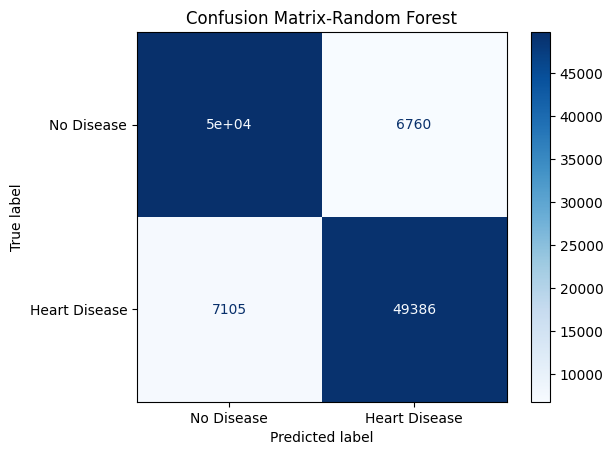

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix-Random Forest")
plt.show()

c:\Users\MSI\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [16:29:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 0.8855

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.88      0.89      0.89     56509
Heart Disease       0.89      0.88      0.88     56491

     accuracy                           0.89    113000
    macro avg       0.89      0.89      0.89    113000
 weighted avg       0.89      0.89      0.89    113000



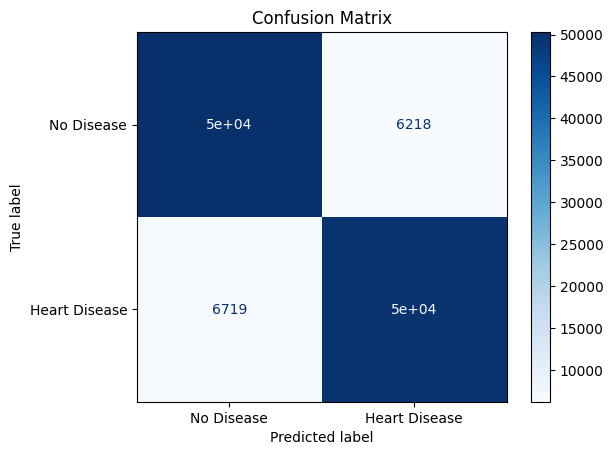


Top Features:
                    Feature  Importance
6                  Thallium    0.586720
8           Chest pain type    0.128366
9           Exercise angina    0.085322
0   Number of vessels fluro    0.061067
10              Slope of ST    0.056568
7                       Sex    0.044133
1             ST depression    0.017610
5                    Max HR    0.013512
2                       Age    0.004566
3               Cholesterol    0.001275


In [5]:
from xgboost import XGBClassifier

# -----------------------------
# 1️⃣ Select features
numerical_features = ["Number of vessels fluro", "ST depression", "Age", "Cholesterol", "BP", "Max HR","Thallium"]
categorical_features = ["Sex", "Chest pain type", "Exercise angina", "Slope of ST"]

# One-hot encode categorical features
X_cat = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine numerical + categorical features
X = pd.concat([df[numerical_features], X_cat], axis=1)
y = df["Heart Disease"]

# -----------------------------
# 2️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 3️⃣ Scale numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

# -----------------------------
# 4️⃣ Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=350,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

# -----------------------------
# 5️⃣ Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

# -----------------------------
# 6️⃣ Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# 7️⃣ Feature Importance
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:")
print(importances.head(10))